# 02 - CV: cyclic-voltammetry-style voltage sweep

In electrochemistry, CV usually means cyclic voltammetry: sweep the voltage
and measure the current response. This workbook focuses on that
voltage-sweep meaning of CV.

Docs:

- Experiment step functions: https://docs.pybamm.org/en/stable/source/api/experiment/experiment_steps.html
- Custom experiments: https://docs.pybamm.org/en/stable/source/examples/notebooks/simulations_and_experiments/custom-experiments.html

In [ ]:
import os

os.environ.setdefault("PYBAMM_DISABLE_TELEMETRY", "true")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import pybamm

print("PyBaMM version:", pybamm.__version__)

PyBaMM version: 26.6.2.0


## Important formulas

Scan rate:

$$
\nu = \frac{dV}{dt}
$$

Current is the rate of charge flow:

$$
I = \frac{dQ}{dt}
$$

The usual CV view is current versus voltage. PyBaMM uses positive current
for discharge and negative current for charge, so the sign may be opposite
to some electrochemistry conventions.

In [2]:
def triangular_voltage_profile(vertices, scan_rate_v_per_h=0.25, sample_period_s=60):
    scan_rate_v_per_s = scan_rate_v_per_h / 3600
    times = [0.0]
    voltages = [float(vertices[0])]
    t_total = 0.0

    for v0, v1 in zip(vertices[:-1], vertices[1:]):
        duration = abs(v1 - v0) / scan_rate_v_per_s
        n = max(2, int(np.ceil(duration / sample_period_s)))
        t_segment = np.linspace(t_total, t_total + duration, n + 1)[1:]
        v_segment = np.linspace(v0, v1, n + 1)[1:]
        times.extend(t_segment)
        voltages.extend(v_segment)
        t_total += duration

    return np.column_stack([times, voltages])


model = pybamm.lithium_ion.DFN()
parameter_values = model.default_parameter_values

# Start near the initial cell voltage to avoid a large artificial current spike.
vertices = [3.8, 4.0, 3.5, 3.8]
scan_rate_v_per_h = 0.25
profile = triangular_voltage_profile(vertices, scan_rate_v_per_h)

experiment = pybamm.Experiment(
    [pybamm.step.voltage(profile, period="60 seconds")]
)

sim = pybamm.Simulation(
    model,
    parameter_values=parameter_values,
    experiment=experiment,
    output_variables=["Voltage [V]", "Current [A]"],
)
solution = sim.solve(initial_soc=0.5)

print(f"CV sweep duration: {solution['Time [h]'].entries[-1]:.2f} h")

CV sweep duration: 4.00 h


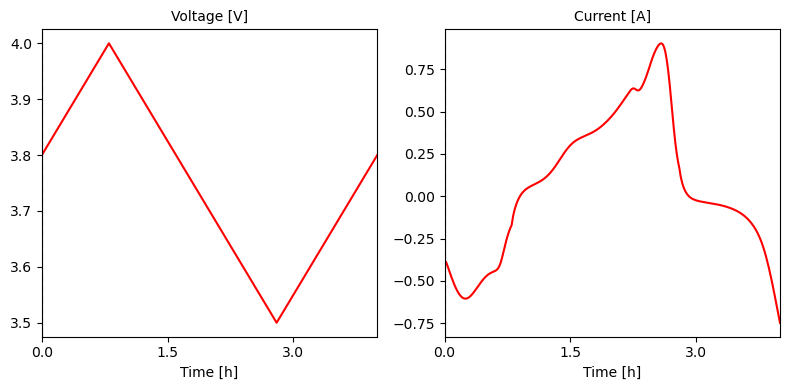

In [3]:
pybamm.QuickPlot(solution, ["Voltage [V]", "Current [A]"]).plot(0)

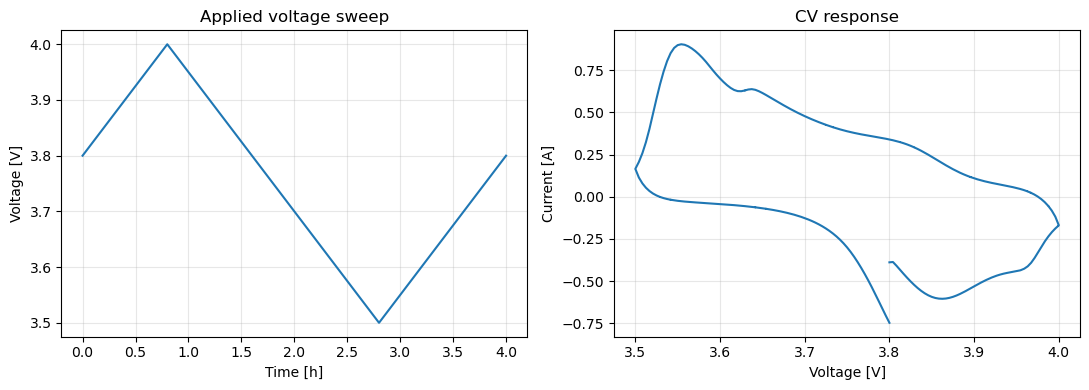

In [4]:
voltage = solution["Voltage [V]"].entries
current = solution["Current [A]"].entries
time_h = solution["Time [h]"].entries

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(time_h, voltage)
axes[0].set_xlabel("Time [h]")
axes[0].set_ylabel("Voltage [V]")
axes[0].set_title("Applied voltage sweep")
axes[0].grid(True, alpha=0.3)

axes[1].plot(voltage, current)
axes[1].set_xlabel("Voltage [V]")
axes[1].set_ylabel("Current [A]")
axes[1].set_title("CV response")
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## Try changing the scan rate

Larger scan rates usually increase polarization, so the same voltage sweep
demands a larger current response. Change `scan_rate_v_per_h` below and
rerun the cell.

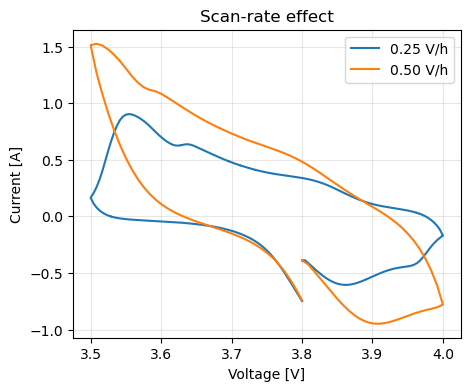

In [5]:
scan_rate_v_per_h = 0.50
profile_fast = triangular_voltage_profile(vertices, scan_rate_v_per_h)
experiment_fast = pybamm.Experiment(
    [pybamm.step.voltage(profile_fast, period="60 seconds")]
)
sim_fast = pybamm.Simulation(
    pybamm.lithium_ion.DFN(),
    parameter_values=parameter_values,
    experiment=experiment_fast,
    output_variables=["Voltage [V]", "Current [A]"],
)
solution_fast = sim_fast.solve(initial_soc=0.5)

plt.figure(figsize=(5, 4))
plt.plot(solution["Voltage [V]"].entries, solution["Current [A]"].entries, label="0.25 V/h")
plt.plot(solution_fast["Voltage [V]"].entries, solution_fast["Current [A]"].entries, label="0.50 V/h")
plt.xlabel("Voltage [V]")
plt.ylabel("Current [A]")
plt.title("Scan-rate effect")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()